# Nonlinear Heat Conduction Problem with hyper-reduction, reduction and full order simulation

![Problem Schematic](problem_schematics.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.masterclass as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
import skrom.rom.deim.deim as deim_module
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

PETSc available: True


### Plot Properties


In [3]:
# # Define a custom color palette with 19 distinct colors
import sci_mplstyle_package
set_color_palette();

In [4]:
generate_data = False
visualize = True
run_svd = True
run_rom = True
run_hyperrom = True
rom_report = True

_hyperreduce_ecsw = True
_hyperreduce_ecm = True
_hyperreduce_deim = True

## Full Order Simulation


In [5]:
# Control flag for expensive simulation generation
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


### Load Simulation Data

In [6]:
#Load the ROM_data
# current_dir = Path().resolve()
# rom_dir = current_dir / "ROM_data"
# fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\non_linear\problem_1_h\ROM_data


---

## Data Generation

### Generate Training Solution Dataset



In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(rom_data.param_list)

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

32


### Training Solution Snapshots


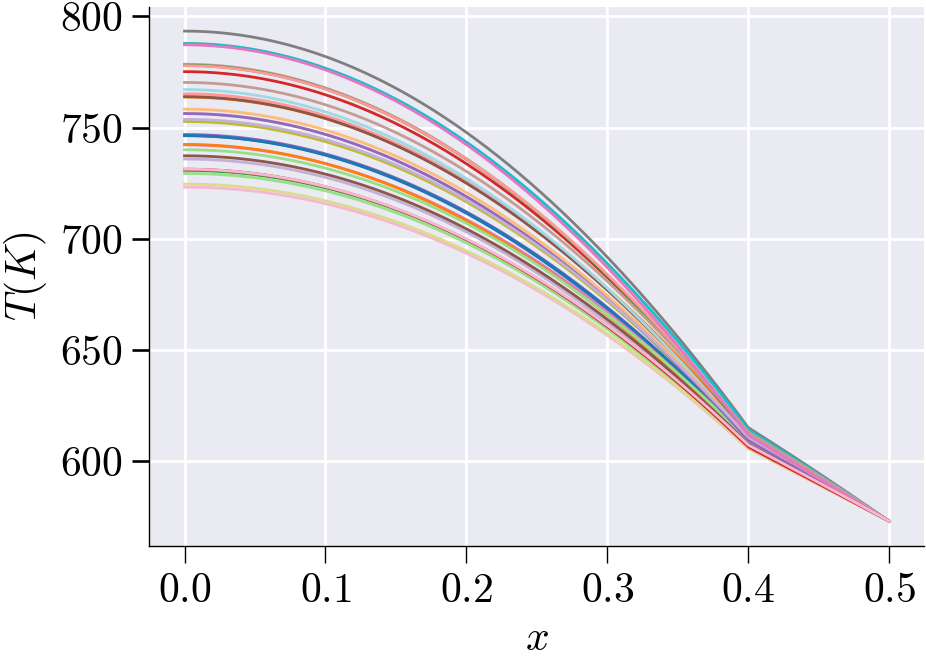

In [8]:
if visualize:

    # Plot the computed temperature distribution
    # Create a figure with specified dimensions (5x3.5 inches) for compact visualization
    plt.figure(figsize=(5, 3.5))

    # Extract spatial coordinates from the mesh data
    # The mesh is stored as an object in rom_data
    # mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
    mesh_domain = rom_data.mesh.p[0]

    # Plot temperature profiles for all parameter combinations
    # Loop through all non-linear solutions (each row is a complete temperature field)
    for j in range(len(NLS)):
        # Plot each temperature distribution as a line
        # x-axis: spatial coordinates from the mesh
        # y-axis: temperature values at each spatial location
        # '-' specifies solid line style, markersize affects any markers
        plt.plot(mesh_domain, NLS[j], '-', markersize=2)

    # Set axis labels with proper mathematical notation
    plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
    plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

    # Display the plot
    plt.show()

### Mean Subtraction

In [9]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

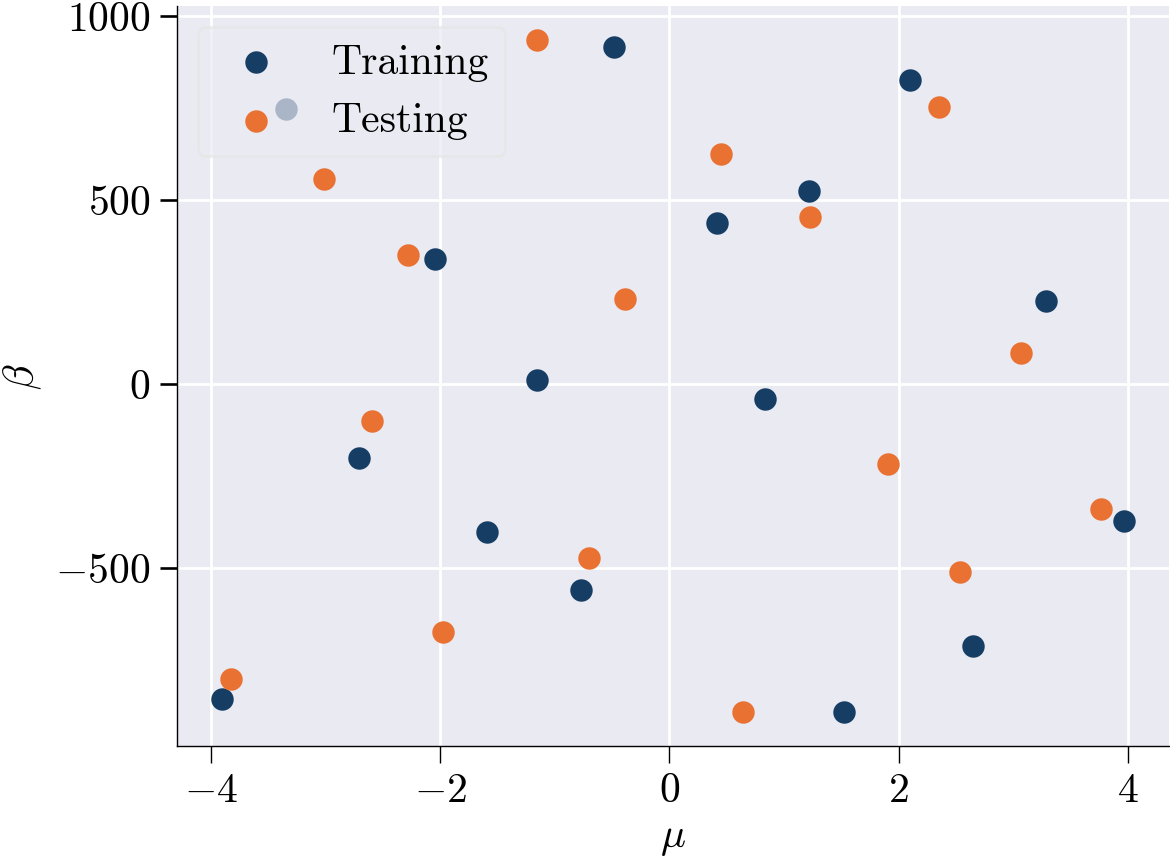

In [10]:
if visualize:

    # Visualize the parameter space distribution for training and testing data
    # Plot training parameter combinations (first 16 samples)
    # Extract first and second parameter columns for 2D visualization
    plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
            param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
            s=50,                      # Marker size
            c='#163e64',              # Dark blue color for training points
            label="Training")         # Legend label

    # Plot testing parameter combinations (samples 17 and beyond)
    plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
            param_list[16:][:, 1],     # Second parameter (β) for testing samples
            s=50,                      # Marker size (same as training)
            c='#e97132',              # Orange color for testing points
            label="Testing")          # Legend label

    # Set axis labels using LaTeX formatting for mathematical notation
    plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
    plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

    # Add legend to distinguish between training and testing sets
    plt.legend()

    #See params and properties to see how these are used

### Training Snapshots after mean subtraction

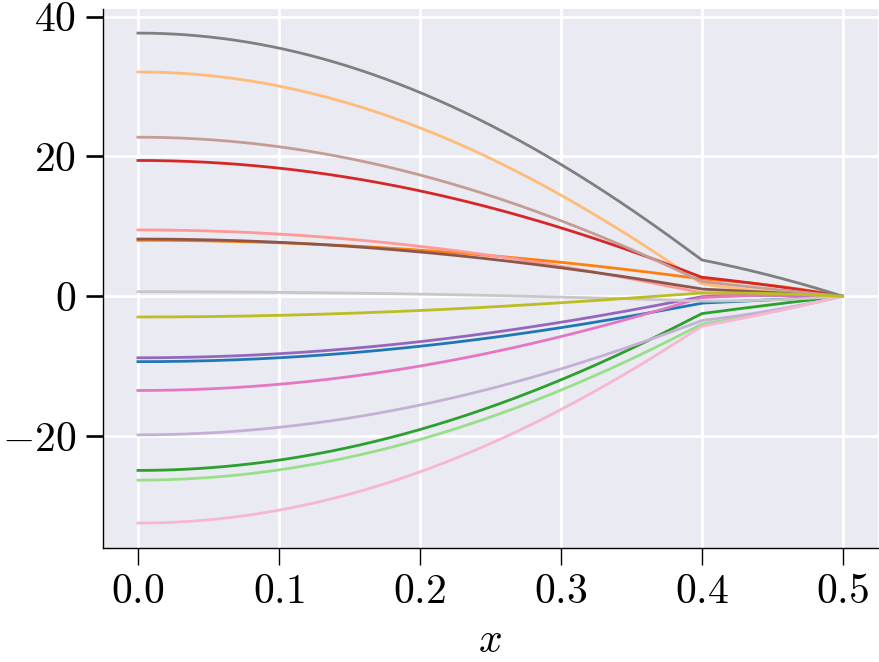

In [11]:
if visualize:

    # Create figure with subplot for better control over the plot
    fig, ax = plt.subplots(figsize=(5, 3.5))

    # Apply the custom color cycle to this specific plot
    # This ensures consistent coloring with the earlier defined palette


    # Extract spatial coordinates (degrees of freedom locations) from the finite element basis
    # These represent the x-coordinates where the temperature values are computed
    mesh_domain = rom_data.basis.doflocs[0]

    # Plot all mean-centered temperature profiles from the training set
    for i in range(len(NLS_train_ms)):
        # Plot each mean-centered temperature fluctuation profile
        # x-axis: spatial coordinate locations (DOF locations)
        # y-axis: temperature deviation from mean (fluctuations around zero)
        # Commented line shows alternative approach using different coordinate system
        # ax.plot(d.xi[0][:-1], LS_train_ms[i])
        ax.plot(mesh_domain, NLS_train_ms[i])

    # Set x-axis label with mathematical formatting
    plt.xlabel('$x$')  # Spatial coordinate

### Performing SVD on training snapshots

Number of modes selected: 4


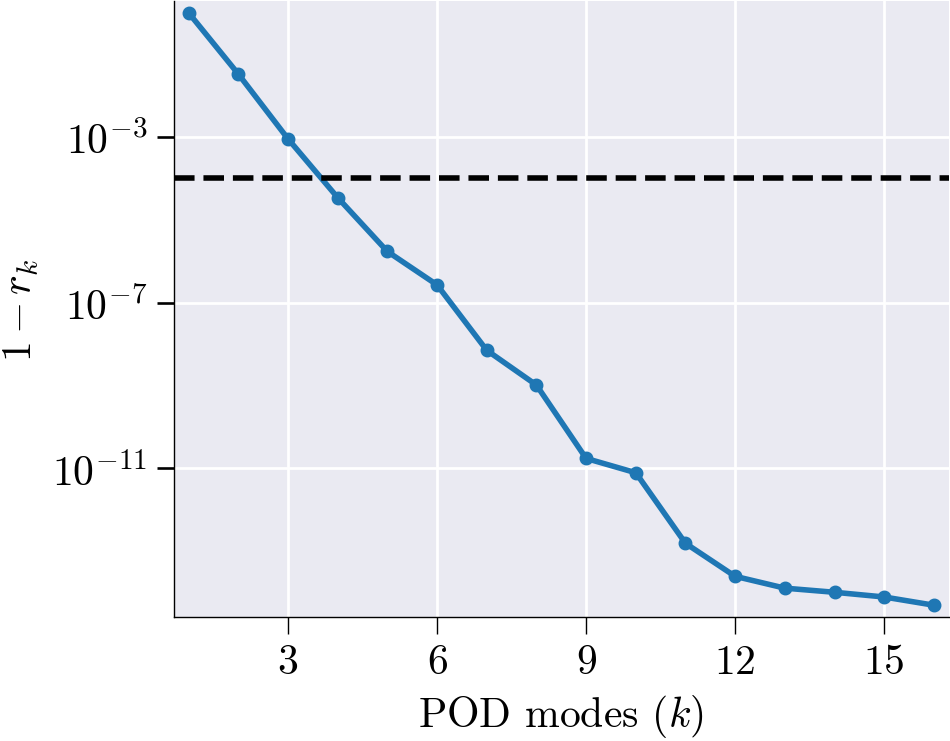

In [12]:
if run_svd:

    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
    plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

    # Perform Singular Value Decomposition (SVD) for POD mode selection
    # SVD decomposes the mean-centered training data to find optimal basis functions
    n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                                tolerance=1e-4,    # Convergence criterion for mode selection
                                modes=True)        # Return both number of modes and basis vectors


    # Extract the selected POD basis vectors (spatial modes)
    # V_sel contains the first n_sel most energetic POD modes
    # Shape: [N_dof, n_sel] - each column is a spatial basis function
    V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

    # Set axis labels for the POD energy plot (generated by svd_mode_selector)
    plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
    plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

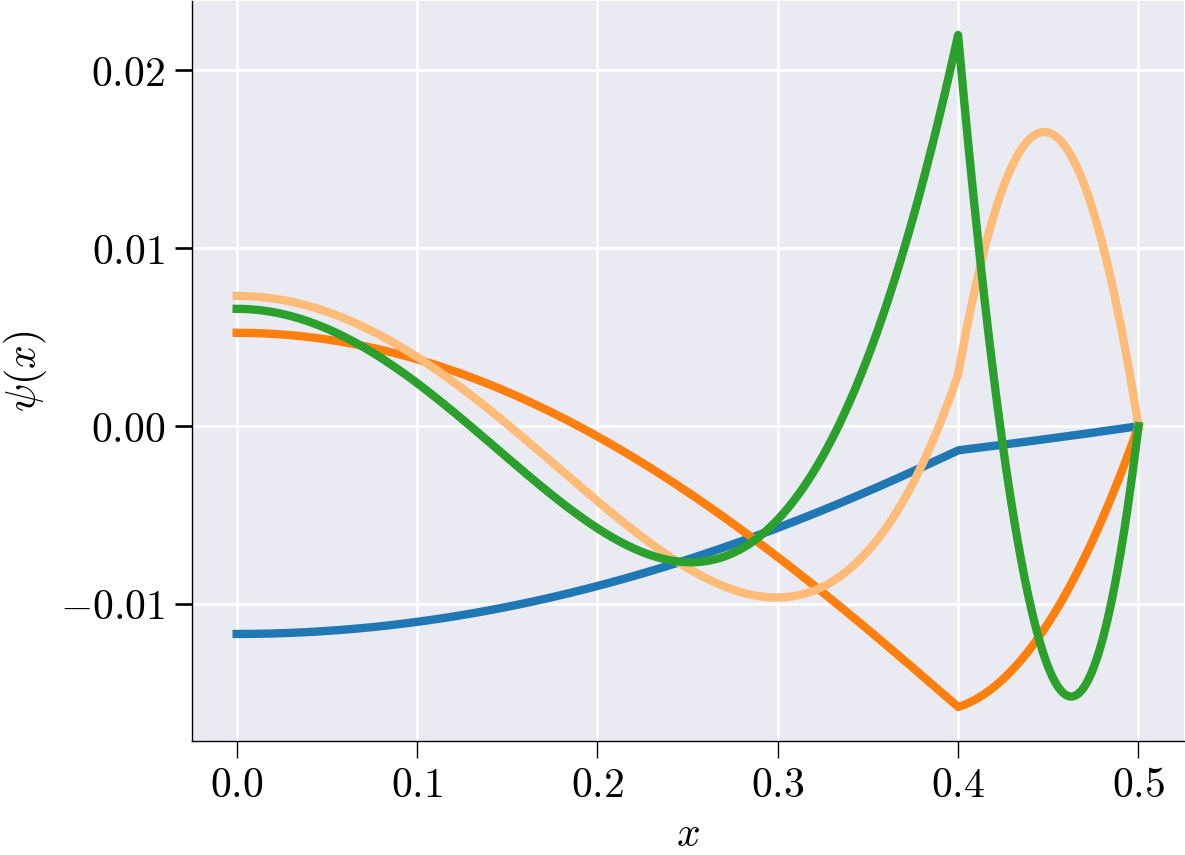

In [13]:
if visualize:
    # Create figure and axis for POD modes visualization
    fig, ax = plt.subplots()



    # Plot all selected POD spatial modes
    for i in range(n_sel):
        # Plot each POD mode as a function of spatial coordinate
        # x-axis: spatial locations (DOF coordinates)
        # y-axis: POD mode amplitude at each spatial location
        # lw=3: Use thick lines for better visibility of mode shapes
        plt.plot(mesh_domain, V_sel[:, i], lw=3)

    # Set axis labels with mathematical notation
    ax.set_xlabel('$x$')        # Spatial coordinate
    ax.set_ylabel('$\\psi(x)$')  # POD mode amplitude (basis function value)

    # Control the number of y-axis ticks for cleaner appearance
    # nbins=5: Limit to approximately 5 major tick marks on y-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # Display the plot
    plt.show()

---

## ROM Simulation


In [14]:
if run_rom:
    
    # Initialize the reduced-order model (ROM) simulation
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    #   n_sel : number of basis vectors (modes) to retain in the ROM
    rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel, train_ref=NLS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\non_linear\problem_1_h\ROM_data


In [15]:
if run_rom:

    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    generate = True
    if generate:
        rom.run_rom_simulation();
    #Returns the Newton iteration errors just like full order simulation

Snap 1/16 params=[   3.76410387 -337.65399829]
[ROM Newton] Iter  0, step norm = 2.341e+03
[ROM Newton] Iter  2, step norm = 3.774e-05
Snap 2/16 params=[ -3.01457155 557.87141435]
[ROM Newton] Iter  0, step norm = 3.366e+03
[ROM Newton] Iter  2, step norm = 3.545e-04
Snap 3/16 params=[  -1.97320058 -671.88826576]
[ROM Newton] Iter  0, step norm = 1.663e+03
[ROM Newton] Iter  2, step norm = 1.968e-05
Snap 4/16 params=[  1.22273388 455.56698553]
[ROM Newton] Iter  0, step norm = 9.368e+02
[ROM Newton] Iter  2, step norm = 1.041e-07
Snap 5/16 params=[ 6.40152551e-01 -8.90137097e+02]
[ROM Newton] Iter  0, step norm = 1.065e+03
[ROM Newton] Iter  2, step norm = 1.449e-06
Snap 6/16 params=[ -0.38976596 231.45779222]
[ROM Newton] Iter  0, step norm = 1.148e+03
[ROM Newton] Iter  2, step norm = 5.547e-06
Snap 7/16 params=[ -2.59910454 -99.86346029]
[ROM Newton] Iter  0, step norm = 2.538e+03
[ROM Newton] Iter  2, step norm = 1.143e-04
Snap 8/16 params=[  2.34949207 754.64545935]
[ROM Newton] I

In [16]:
if rom_report:
    
    #Assign values for the statistics
    NLS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up
    ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 8.8522e-04
Relative L2 Error:        4.0298e-08
L∞ Error:                 9.6433e-05
Relative L∞ Error:        1.2240e-07
RMSE:                     2.7663e-05
MAE:                      2.0767e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             1.2439e-08
95th Percentile Error:    5.1785e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.1420e-09
Max Rel L2 Error over time/parameter: 5.7326e-09
Min Rel L2 Error over time/parameter: 2.2794e-10
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

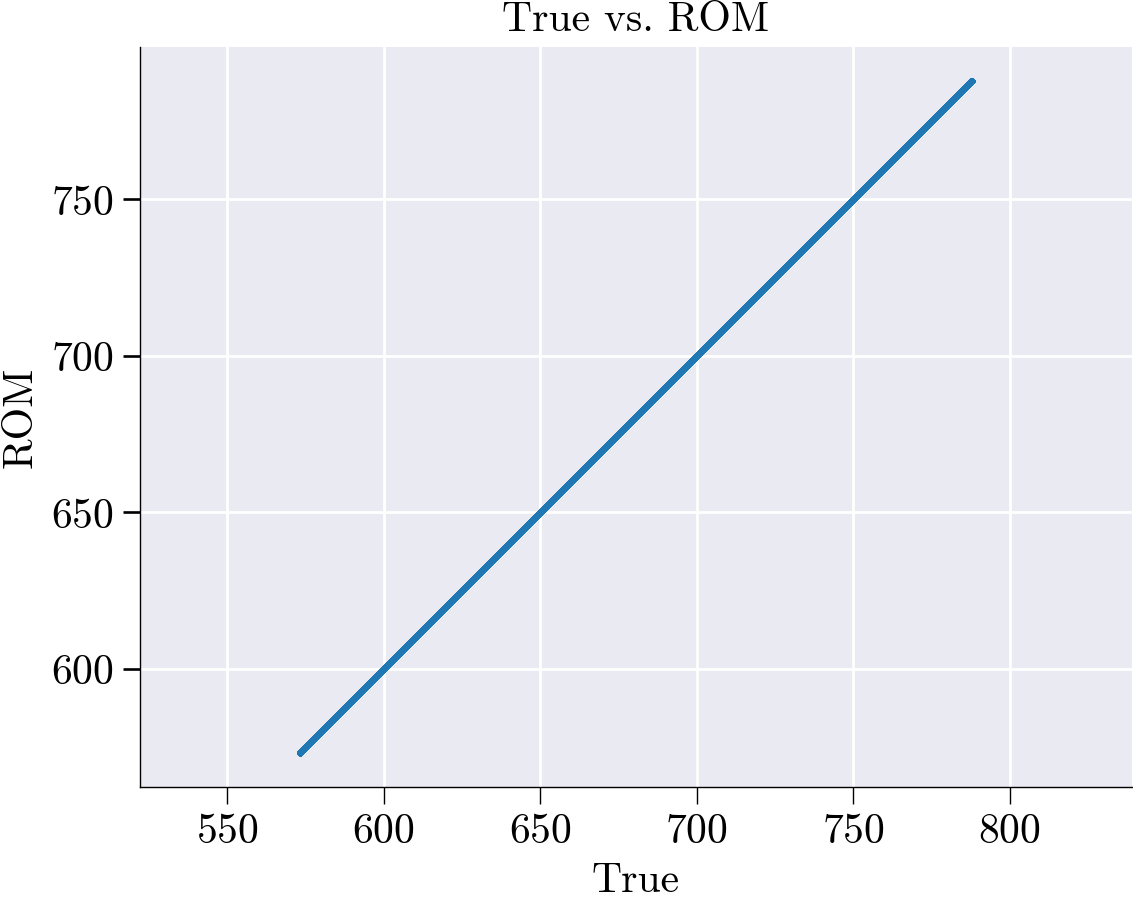

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


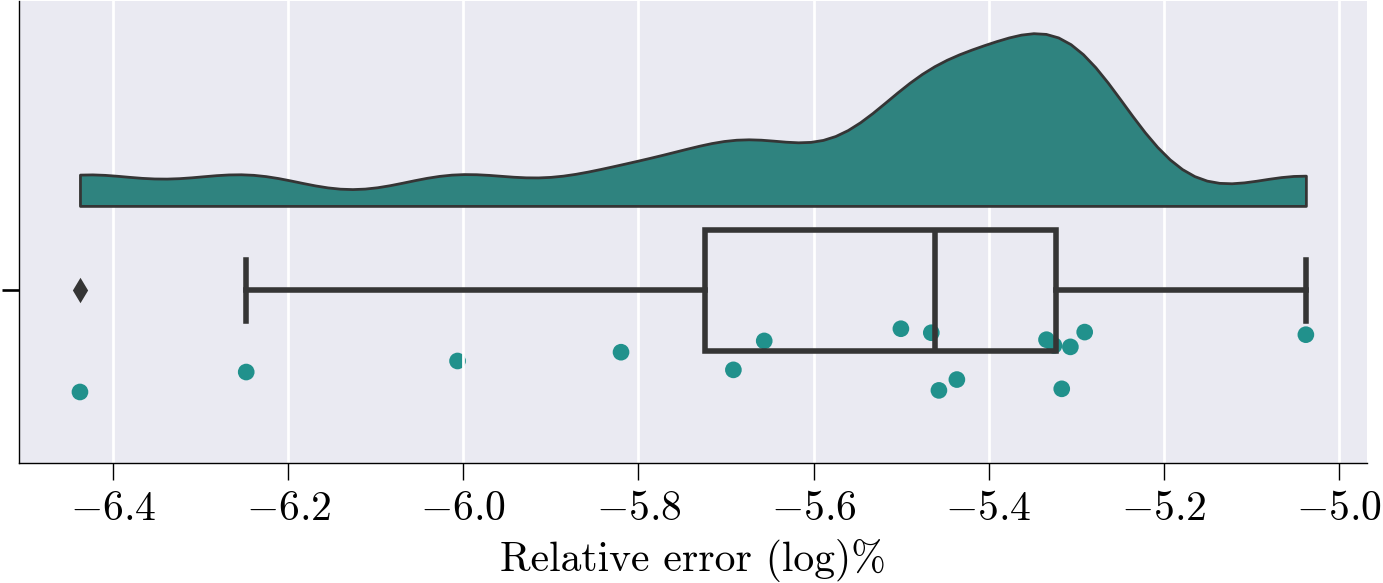

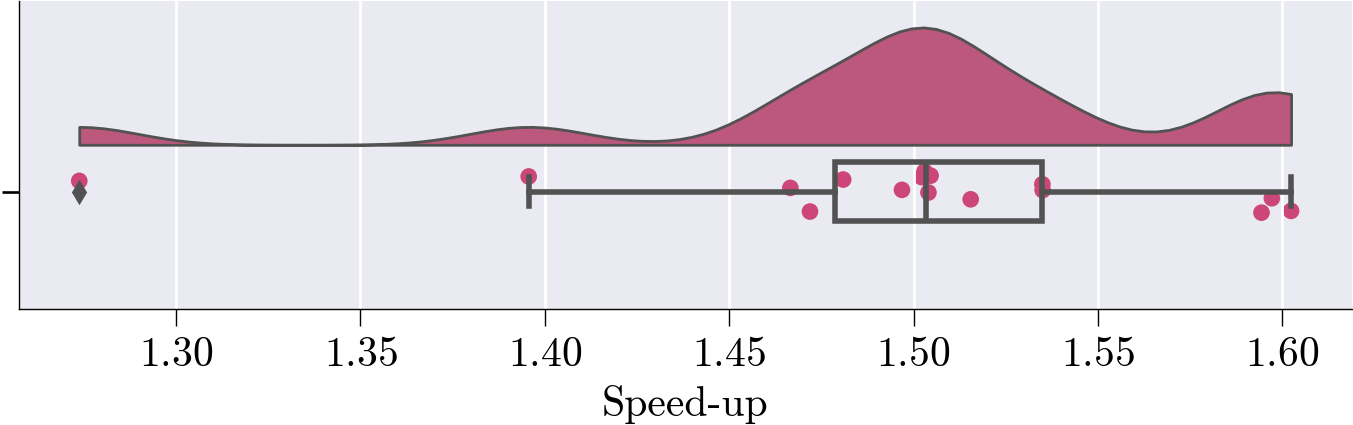

In [17]:
if rom_report:

    # --- Standard ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
    matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

    # Produce a text-based report summarizing these error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the standard ROM
    plot_rom_error_diagnostics_flat(
        NLS_test,               # full-order (true) solution snapshots
        NLS_rom,                # ROM-generated solution snapshots
        ROM_relative_error,     # precomputed relative error of the ROM
        ROM_speed_up,           # precomputed speed-up factor of the ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix          # the matrix of error metrics just computed
    )


---

## Hyper ROM Simulation


### 1. ECSW

#### Mesh Sampling


In [18]:
if _hyperreduce_ecsw:

    from skrom.rom.ecsw.hyperreduce import hyperreduce

    prob = ProblemNonLinear()
    # sim_data['free_dofs'] = prob.domain()['free_dofs']
    # sim_data['dirichlet_boundary_dofs'] = prob.domain()['dirichlet_boundary_dofs']
    # sim_data['global_mask'] = prob.domain()['global_mask']
    # Extract free degrees of freedom (DOFs) 
    free_dofs = prob.domain()['free_dofs']
    basis = rom_data.basis


In [19]:
if _hyperreduce_ecsw:
    # Create the ROM residual linear form object
    # This represents the linear form R(u,v) in the weak formulation of the PDE
    Residual = LinearFormROM(R,                    # Linear form function from problem definition
                            basis,                 # Finite element basis functions
                            V_sel,                 # Selected POD modes (reduced basis)
                            free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

    # Extract parameter values corresponding to training snapshots
    # Uses the boolean mask to get only the parameter combinations used for training
    training_params = param_list[train_mask]

In [20]:
if _hyperreduce_ecsw:

    # Collect residual evaluations for all training snapshots
    # This creates the dataset needed for hyperreduction of nonlinear ROM terms
    q_mus = collect_residuals(
        NLS_train_ms,         # Mean-centered training snapshots
        NLS_train_mean,       # Mean temperature field
        V_sel,                # Selected POD basis modes
        reconstruct_solution, # Solution reconstruction function
        Residual,             # ROM residual operator
        training_params,
        prob.assemble_kwargs,
        extra_kwargs = dict(global_mask = prob.domain()['global_mask'] )
    )

    # Display the shape of collected residuals for verification
    # Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
    print(q_mus.shape)

    #Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(64, 16383)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 127.99609368880147


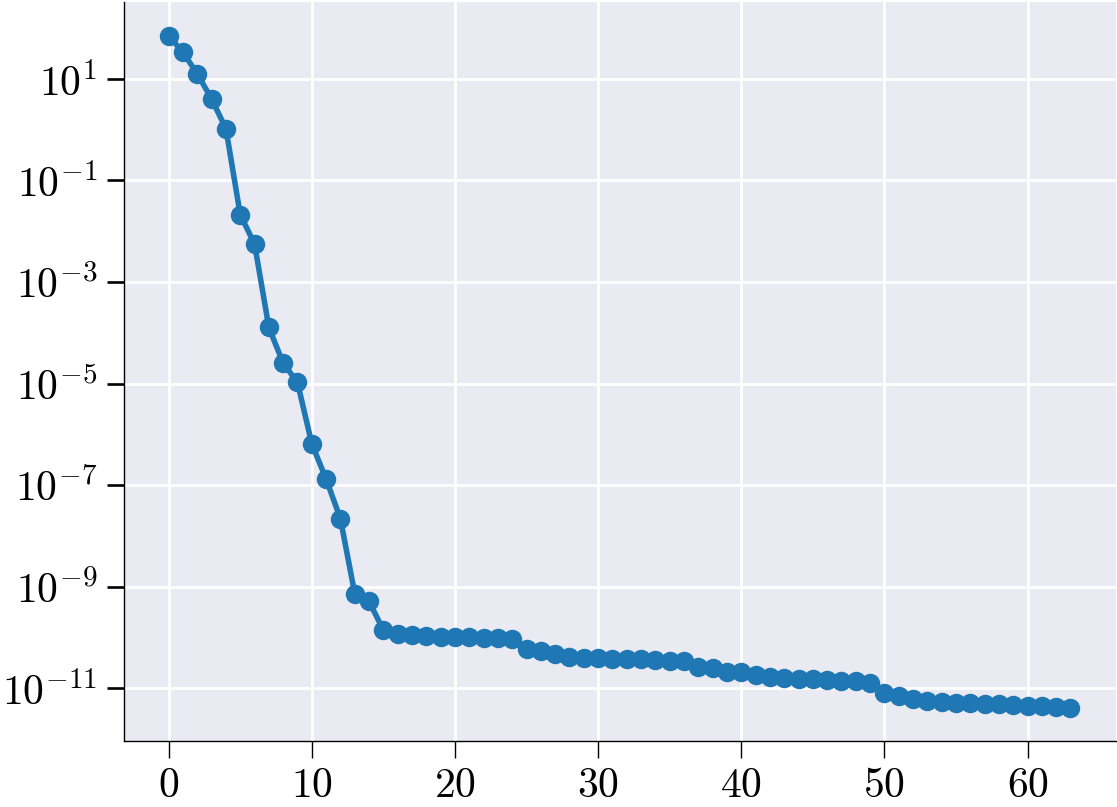

In [21]:
if _hyperreduce_ecsw:
    
    print("Performing SVD...")
    # Performs Singular Value Decomposition on q_mus matrix
    # Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
    Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

    # Plots singular values on a logarithmic y-scale to visualize their decay
    # This helps identify the effective rank/dimensionality of the matrix
    plt.semilogy(s, 'o-')

    # Takes the first 20 right singular vectors (rows of Vh)
    # This creates a reduced basis capturing the most significant modes
    V_q_eff = Vh[:20]

    # Computes a weighted combination of the basis vectors
    # Each basis vector is weighted equally (multiplied by 1)
    # This essentially sums all 20 basis vectors
    d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

    # Outputs the L2 norm of the resulting vector
    # This gives a sense of the magnitude of the combined basis representation
    print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [22]:
if _hyperreduce_ecsw:   
    # Solve the non-negative least squares (NNLS) problem using hyperreduce
    #   V_q_eff   : effective basis matrix
    #   verbosity : level of log output (2 = detailed)
    #   const_tol : tolerance for column selection
    #   zero_tol  : tolerance to treat values as zero
    #   plot      : disable plotting
    x_nnls_m, err = hyperreduce(
        V_q_eff,
        verbosity=2,
        const_tol=1e-8,
        zero_tol=1e-8,
        plot=False
    )

    # Compute and print the relative NNLS reconstruction error:
    #   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
    rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
    rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
    print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 20 16383 0 1.257996138903320e+02 1.279960936888015e+02
1 1 20 16383 1 1.234861998113542e+02 1.270992300037397e+02
2 2 20 16383 2 1.220359047893050e+02 1.259900266029028e+02
3 3 20 16383 3 1.189614984344690e+02 1.248292742750565e+02
4 4 20 16383 4 1.181124469158021e+02 1.241523771303169e+02
5 5 20 16383 5 1.130795209359063e+02 1.219070908178182e+02
6 6 20 16383 6 1.041882458372421e+02 1.164287159905165e+02
7 7 20 16383 7 9.867143149218983e+01 1.134274528265823e+02
8 8 20 16383 8 9.621983106895546e+01 1.123351666489308e+02
9 9 20 16383 9 8.282230252806393e+01 1.031654920409392e+02
10 10 20 16383 10 5.589376793292705e+01 8.615200187694788e+01
11 11 20 16383 11 3.327704783519781e+01 6.143435956395169e+01
12 12 20 16383 12 7.913438939713674e+00 2.183429449274772e+01
13 13 20 16383 13 7.147792208616955e+00 1.649242542461329e+01
14 14 20 16383 14 7.377022889503166e+00 1.322717524297722e+01
15 15 20 16383 15 7.080476390049119e+00

#### Plot Reduced Meshes with weights

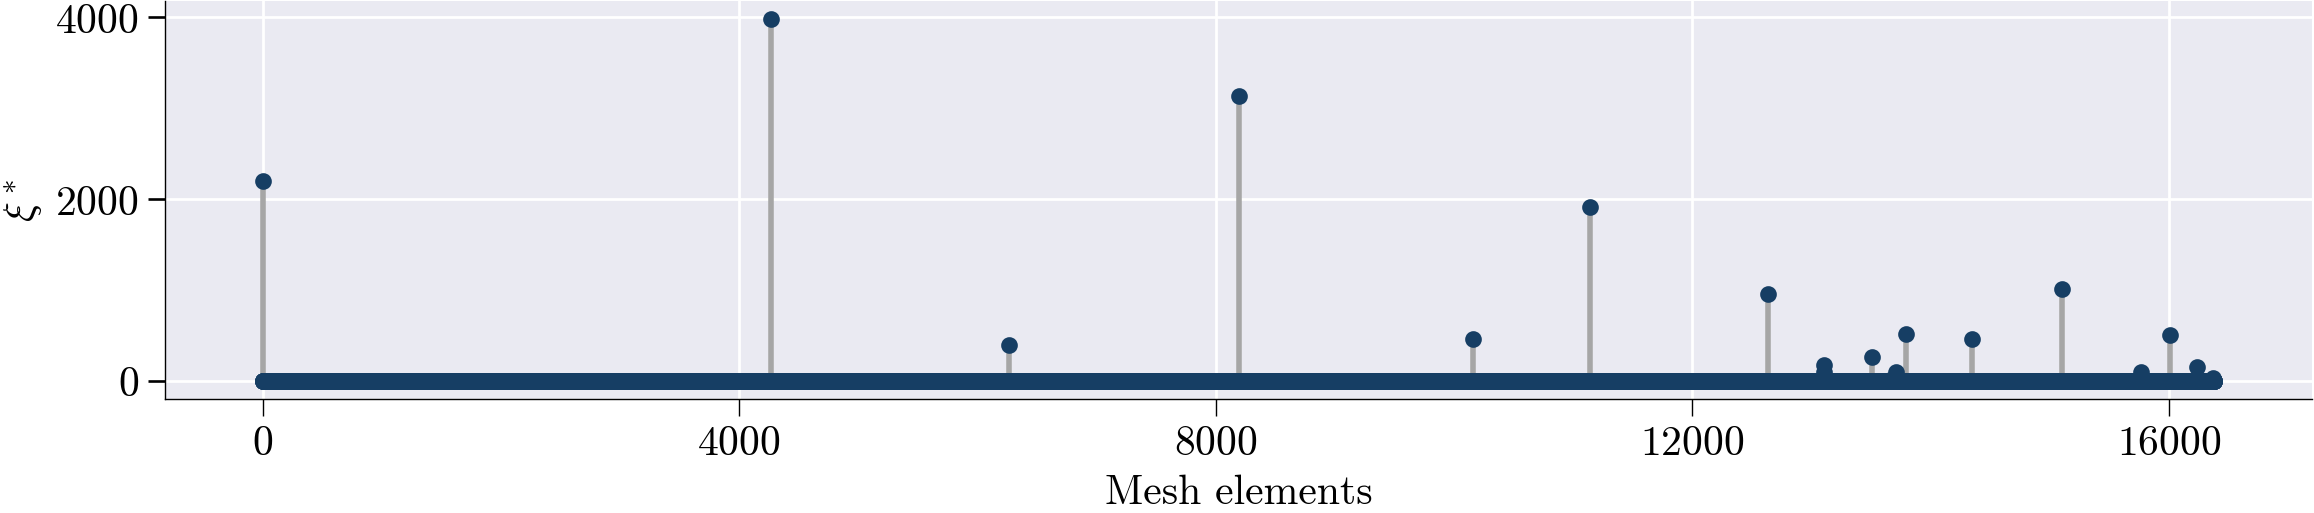

In [23]:
if visualize:
    fig, ax = plot_ecsw_weights(x_nnls_m)

### Run HyperROM simulation


In [24]:
if _hyperreduce_ecsw:
    # Run the hyper-reduced ROM simulation using the NNLS weights
    #   x_nnls_m : array of non-negative least squares coefficients,
    #              used here to weight the reduced basis contributions
    #rom will contain the hyper_rom solution as an attribute
    rom.run_hyper_rom_simulation_ecsw(x_nnls_m);
    #rom.run_hyper_rom_simulation(x_nnls_m)

Snap 1/16 params=[   3.76410387 -337.65399829]
[ROM Newton] Iter  0, step norm = 2.466e+03
[ROM Newton] Iter  3, step norm = 8.384e-03
Snap 2/16 params=[ -3.01457155 557.87141435]
[ROM Newton] Iter  0, step norm = 3.049e+03
[ROM Newton] Iter  4, step norm = 4.414e-03
Snap 3/16 params=[  -1.97320058 -671.88826576]
[ROM Newton] Iter  0, step norm = 1.287e+03
[ROM Newton] Iter  4, step norm = 1.688e-03
Snap 4/16 params=[  1.22273388 455.56698553]
[ROM Newton] Iter  0, step norm = 7.231e+02
[ROM Newton] Iter  4, step norm = 2.179e-04
Snap 5/16 params=[ 6.40152551e-01 -8.90137097e+02]
[ROM Newton] Iter  0, step norm = 1.008e+03
[ROM Newton] Iter  3, step norm = 8.401e-03
Snap 6/16 params=[ -0.38976596 231.45779222]
[ROM Newton] Iter  0, step norm = 7.009e+02
[ROM Newton] Iter  4, step norm = 7.410e-04
Snap 7/16 params=[ -2.59910454 -99.86346029]
[ROM Newton] Iter  0, step norm = 2.204e+03
[ROM Newton] Iter  4, step norm = 2.955e-03
Snap 8/16 params=[  2.34949207 754.64545935]
[ROM Newton] I

In [25]:
if rom_report:
    # Convert the list of nonlinear hyper-ROM solutions into a NumPy array
    NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

    # Retrieve the raw speed-up factors computed by the ROM
    hyper_ROM_speed_up = rom.hyper_speed_up

    # Drop the first element (often the full-order baseline) to analyze only relative speed-ups
    hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

    # Fetch the relative error of the hyper-reduced ROM from the ROM object
    hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 8.8665e-04
Relative L2 Error:        4.0363e-08
L∞ Error:                 9.7925e-05
Relative L∞ Error:        1.2430e-07
RMSE:                     2.7708e-05
MAE:                      2.0784e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             1.9957e-08
95th Percentile Error:    5.2146e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.1452e-09
Max Rel L2 Error over time/parameter: 5.7468e-09
Min Rel L2 Error over time/parameter: 2.3012e-10
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

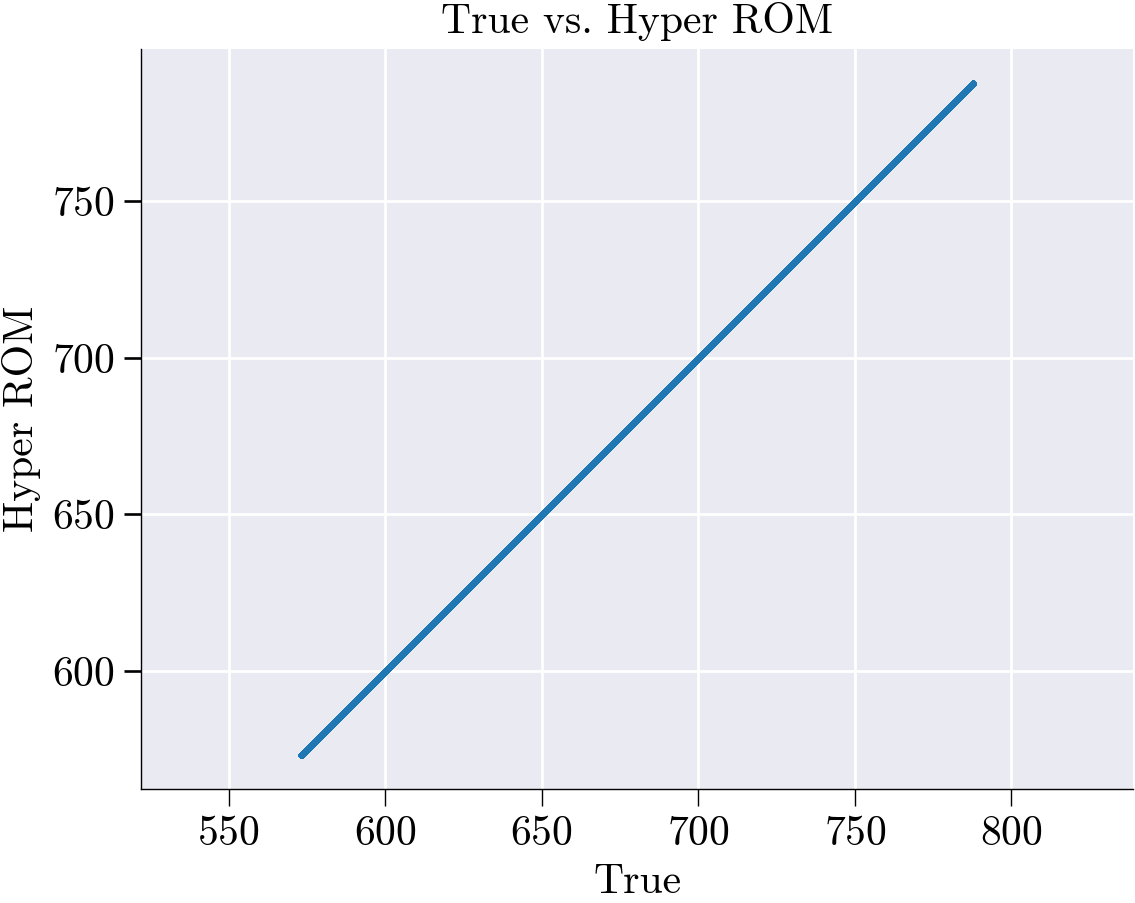

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


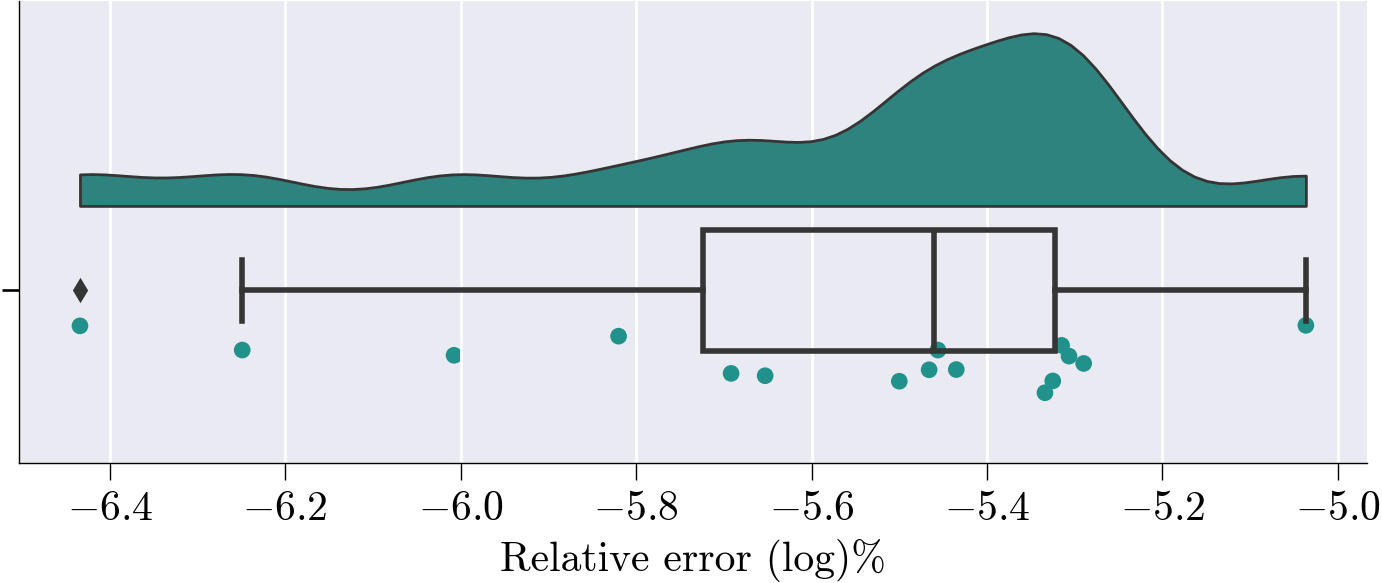

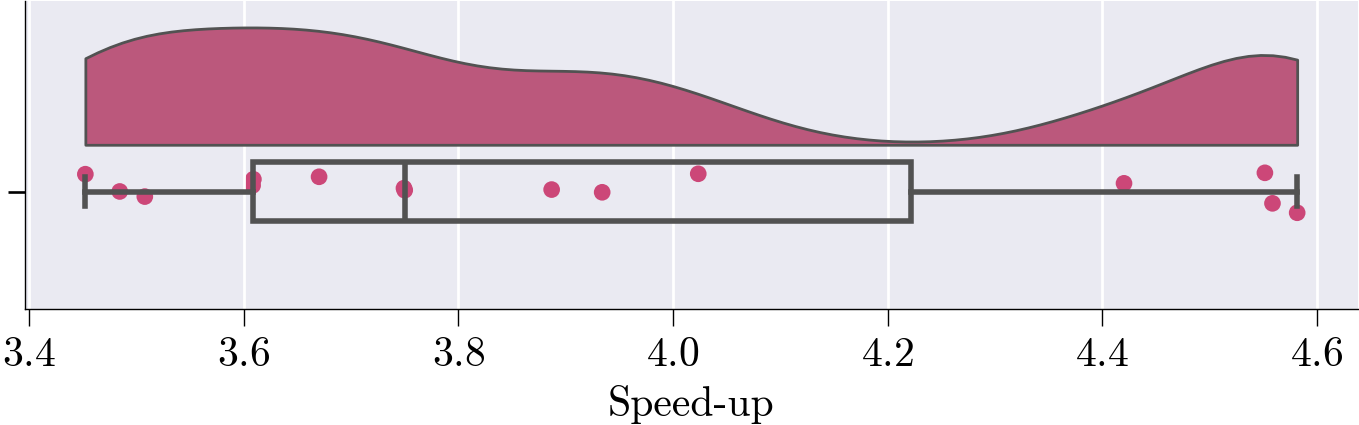

In [26]:
if rom_report:

    # --- Hyper-reduced ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        NLS_test,                   # full-order (true) solution snapshots
        NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
        hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
        hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'Hyper ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )



---

### 2. DEIM

In [31]:
if _hyperreduce_deim:
    prob.basis = basis
    prob.global_mask = prob.domain()['global_mask']
    prob.mesh  = rom_data.mesh
    F_nl = compute_nonlinear_snapshots(
        non_linear_func=prob.f_nl,
        fos_solutions=rom_data.fos_solutions[train_mask],
        param_list=rom_data.param_list[train_mask]
    )

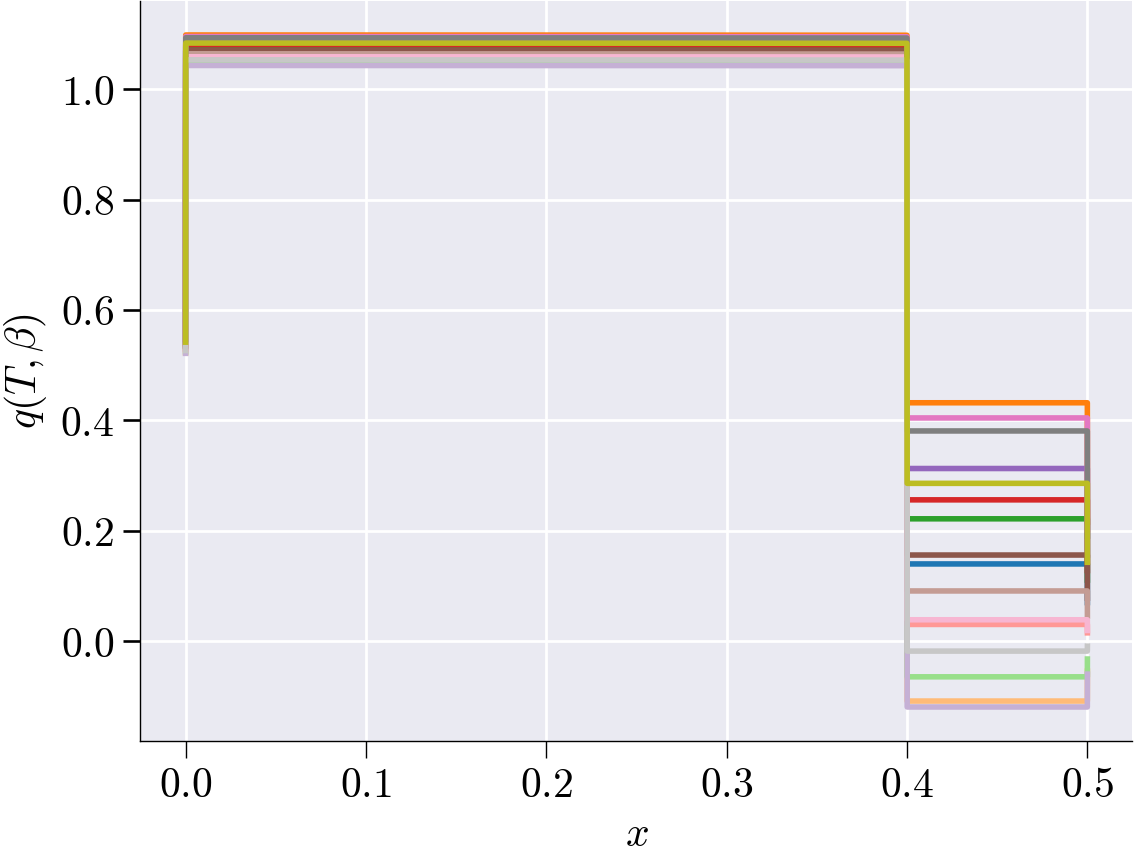

In [32]:
if visualize:
    fig, ax = plt.subplots()
    for i in range(len(F_nl)):
        ax.plot(mesh_domain, F_nl[i])
    plt.xlabel('$x$')
    plt.ylabel('$q(T,\\beta)$')

Selected modes: 4


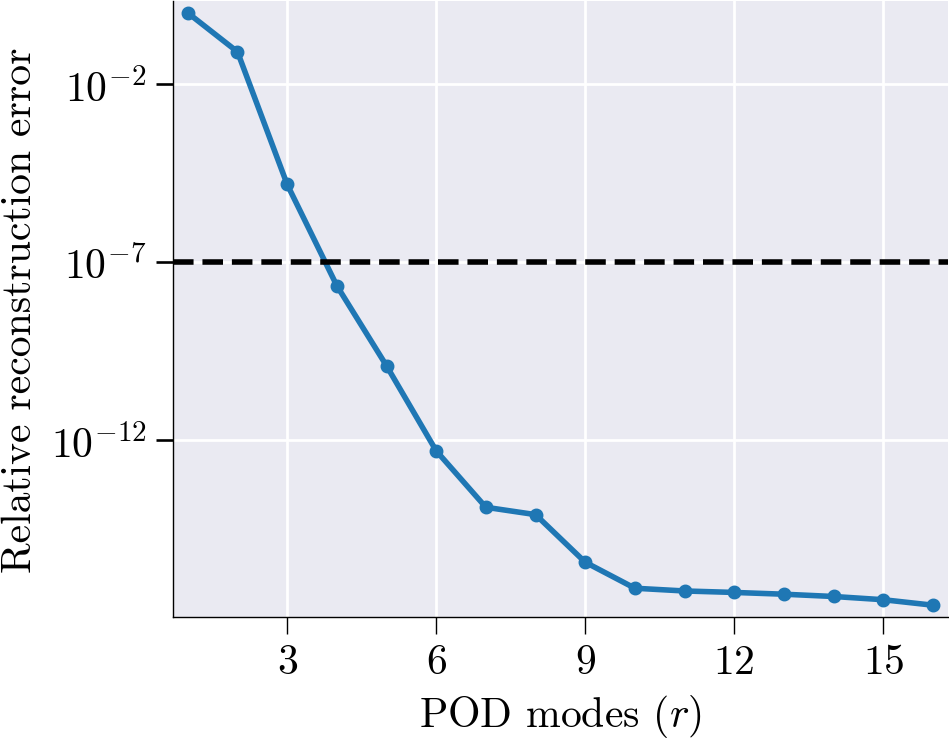

In [33]:
if _hyperreduce_deim:

    # Force snapshots
    deim_class = deim_module.deim(prob.mesh, F_nl, V_sel, tol_f=1e-7, extra_modes =0)

    tic_h_setup_b = time.time()
    deim_mat, sampled_rows = deim_class.select_elems()
    toc_h_setup_b = time.time()

    xi_deim = deim_class.xi
    plt.xlabel('POD modes ($r$)')

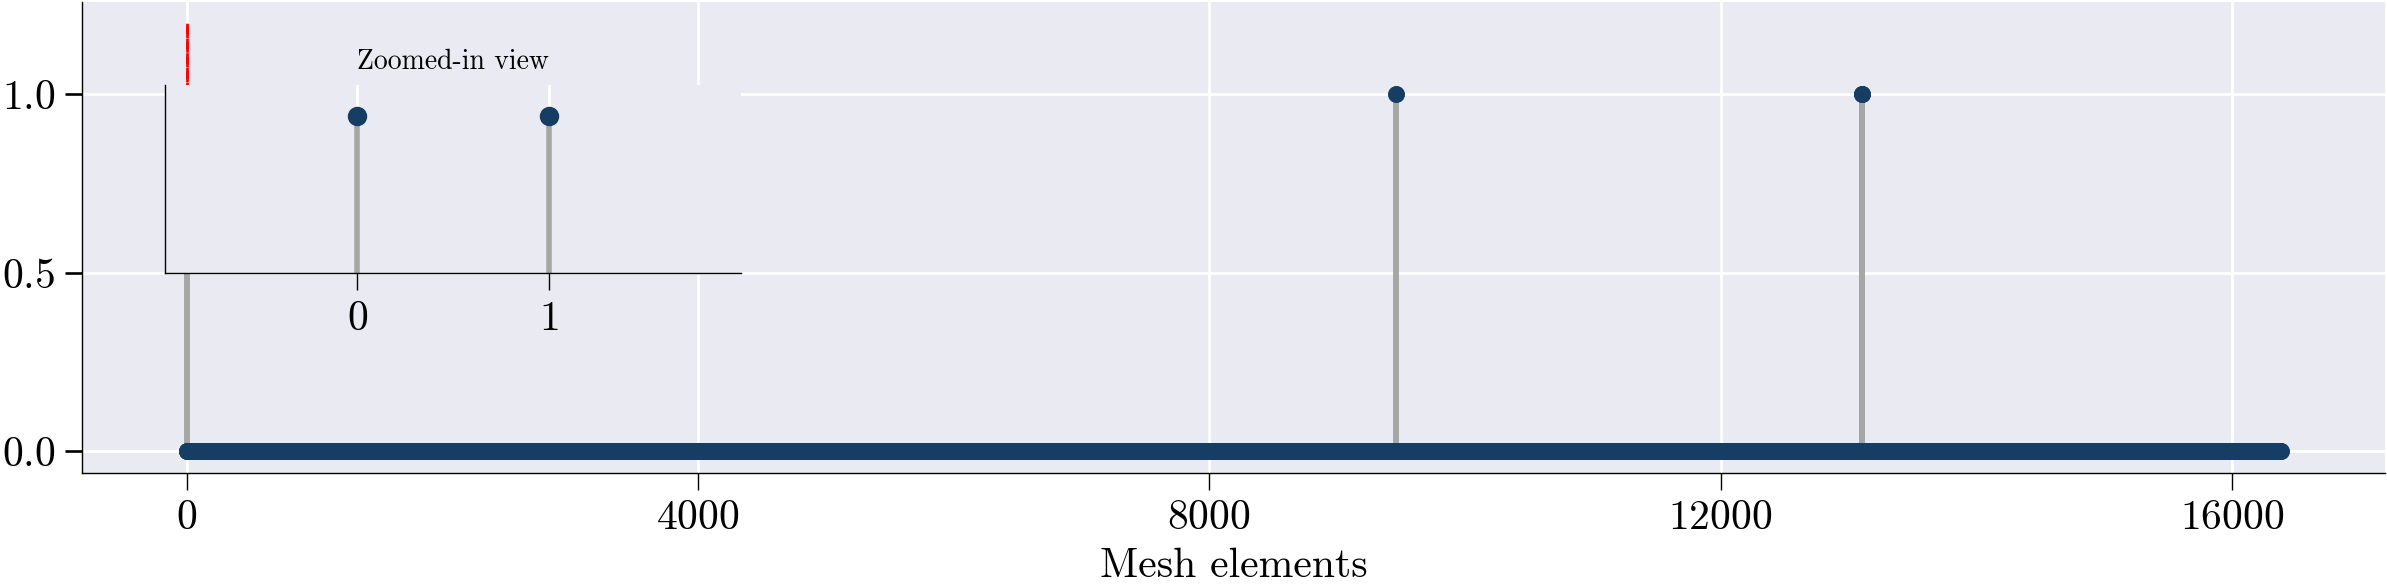

In [34]:
if visualize:
    fig, ax = plot_deim_weights(xi_deim.copy())

In [35]:
if _hyperreduce_deim:
    rom.run_hyper_rom_simulation_deim(z = xi_deim, deim_mat = deim_mat, sampled_rows = sampled_rows);

Snap 1/16 params=[   3.76410387 -337.65399829]
[ROM Newton] Iter  0, step norm = 1.869e+03
[ROM Newton] Iter  5, step norm = 9.611e-03
Snap 2/16 params=[ -3.01457155 557.87141435]
[ROM Newton] Iter  0, step norm = 4.307e+03
[ROM Newton] Iter  6, step norm = 4.902e-03
Snap 3/16 params=[  -1.97320058 -671.88826576]
[ROM Newton] Iter  0, step norm = 2.386e+03
[ROM Newton] Iter  6, step norm = 3.949e-03
Snap 4/16 params=[  1.22273388 455.56698553]
[ROM Newton] Iter  0, step norm = 8.437e+02
[ROM Newton] Iter  6, step norm = 9.841e-04
Snap 5/16 params=[ 6.40152551e-01 -8.90137097e+02]
[ROM Newton] Iter  0, step norm = 6.966e+02
[ROM Newton] Iter  6, step norm = 6.446e-03
Snap 6/16 params=[ -0.38976596 231.45779222]
[ROM Newton] Iter  0, step norm = 1.631e+03
[ROM Newton] Iter  6, step norm = 7.510e-04
Snap 7/16 params=[ -2.59910454 -99.86346029]
[ROM Newton] Iter  0, step norm = 3.393e+03
[ROM Newton] Iter  6, step norm = 7.227e-03
Snap 8/16 params=[  2.34949207 754.64545935]
[ROM Newton] I

In [36]:
if rom_report:

    # Convert the list of nonlinear hyper-ROM solutions into a NumPy array
    NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

    # Retrieve the raw speed-up factors computed by the ROM
    hyper_ROM_speed_up = rom.hyper_speed_up

    # Drop the first element (often the full-order baseline) to analyze only relative speed-ups
    hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

    # Fetch the relative error of the hyper-reduced ROM from the ROM object
    hyper_ROM_relative_error = rom.hyper_rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 3.2475e-01
Relative L2 Error:        1.4784e-05
L∞ Error:                 2.4979e-02
Relative L∞ Error:        3.1707e-05
RMSE:                     1.0148e-02
MAE:                      8.2106e-03

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -1.6749e-03
95th Percentile Error:    2.4001e-02

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 7.7515e-07
Max Rel L2 Error over time/parameter: 2.1147e-06
Min Rel L2 Error over time/parameter: 6.0155e-09
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

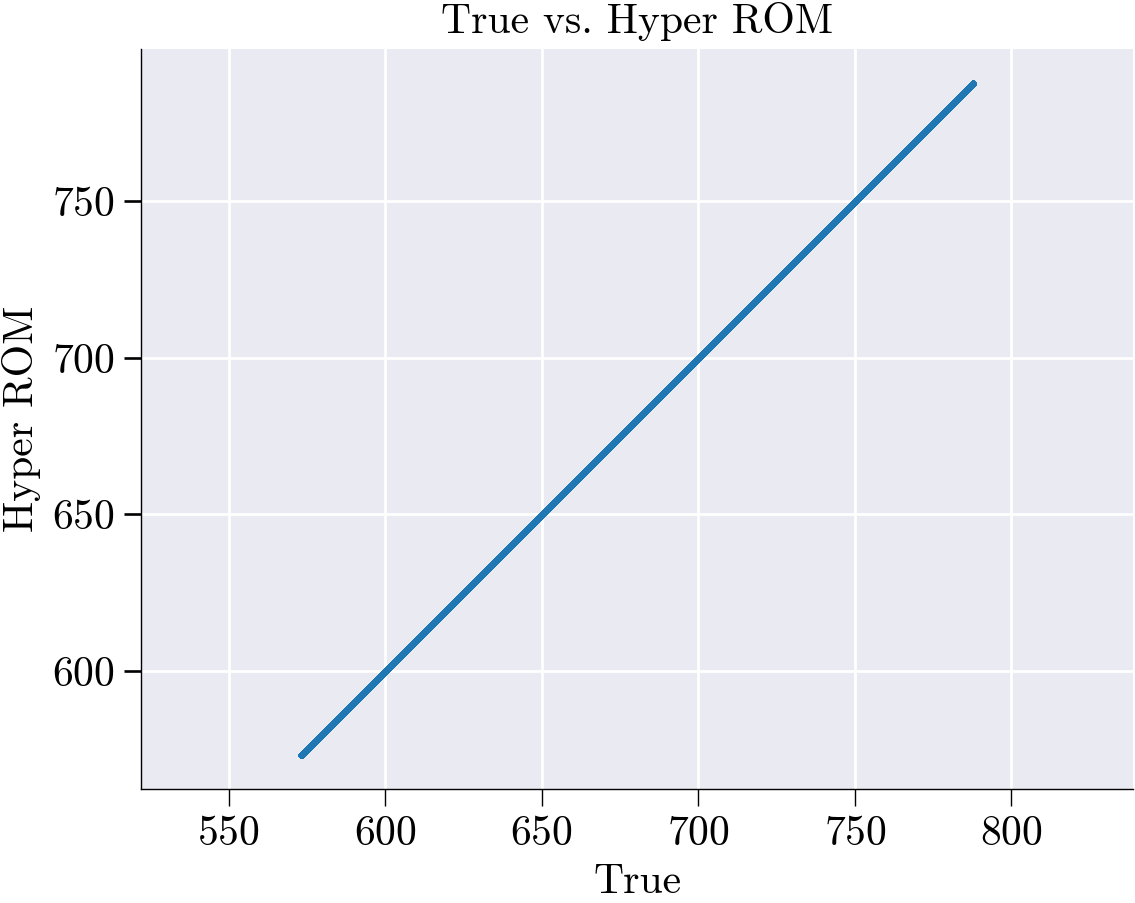

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


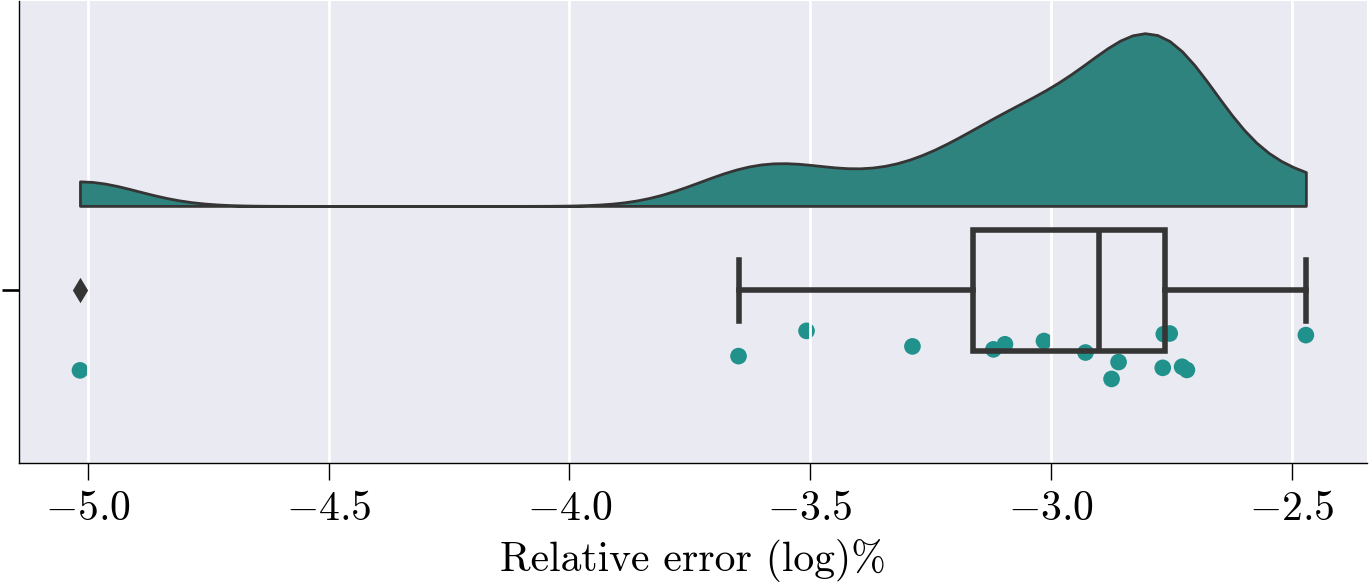

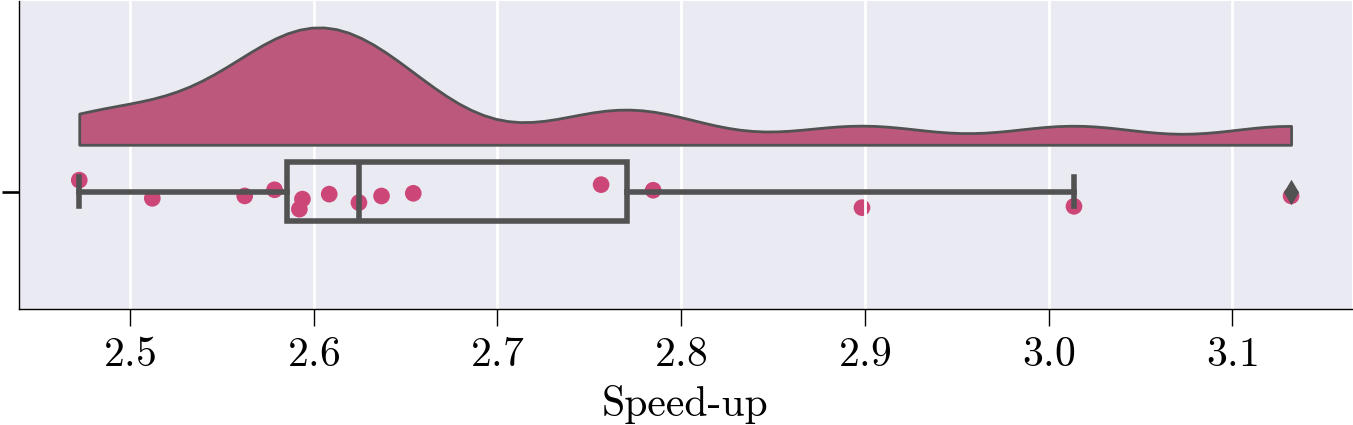

In [37]:
if rom_report:
    # --- Hyper-reduced ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        NLS_test,                   # full-order (true) solution snapshots
        NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
        hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
        hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'Hyper ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )


## ECM workflow

This appended section mirrors the existing ECSW workflow, but collects residual snapshots at the element–Gauss-point level and calls the ECM online solver path.


In [38]:
if _hyperreduce_ecm:
    
    from skrom.rom.rom_utils import collect_residuals_ecm
    from skrom.rom.ecm import train_ecm

In [39]:
if _hyperreduce_ecm:

    Residual_ecm = LinearFormROM(R, basis, V_sel, free_dofs=free_dofs)
    ecm_data = train_ecm.ECM_from_skrom(
        NLS_train_ms=NLS_train_ms,
        NLS_train_mean=NLS_train_mean,
        V_sel=V_sel,
        reconstruct_solution=reconstruct_solution,
        Residual=Residual_ecm,
        training_params=training_params,
        assemble_kwargs=prob.assemble_kwargs,
        basis=basis,
        extra_kwargs=dict(global_mask=prob.domain()['global_mask']),
        tol=1e-8,
        plot=False,
        svd_rank = 30
    )


k = 1, m = 1, error n(res)/n(b) (%) = 98.11748451648327,  Actual error % = 98.11748451648327 
k = 2, m = 2, error n(res)/n(b) (%) = 97.36347862537735,  Actual error % = 97.36347862537735 
k = 3, m = 3, error n(res)/n(b) (%) = 92.30692073021434,  Actual error % = 92.30692073021434 
k = 4, m = 4, error n(res)/n(b) (%) = 83.12691549141408,  Actual error % = 83.12691549141408 
k = 5, m = 5, error n(res)/n(b) (%) = 68.52370188605012,  Actual error % = 68.52370188605012 
k = 6, m = 6, error n(res)/n(b) (%) = 50.50019403349203,  Actual error % = 50.50019403349203 
k = 7, m = 7, error n(res)/n(b) (%) = 49.860138425203544,  Actual error % = 49.860138425203544 
k = 8, m = 8, error n(res)/n(b) (%) = 45.184751805202616,  Actual error % = 45.184751805202616 
k = 9, m = 9, error n(res)/n(b) (%) = 44.29799521274002,  Actual error % = 44.29799521274002 
k = 10, m = 10, error n(res)/n(b) (%) = 37.24571813640223,  Actual error % = 37.24571813640223 
k = 11, m = 11, error n(res)/n(b) (%) = 29.67646370733

D:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\src\skrom\rom\ecm\empirical_cubature_method.py:147: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  alpha = np.linalg.lstsq(self.G[:, [i]], self.b)[0]


In [40]:
if _hyperreduce_ecm:

    gauss_weight_ecm = ecm_data["gauss_weight_ecm"]

In [41]:
if _hyperreduce_ecm:

    # External ECM step
    hyper_rom_error_ecm, hyper_speed_up_ecm = rom.run_hyper_rom_simulation_ecm(gauss_weight_ecm)

Snap 1/16 params=[   3.76410387 -337.65399829]
[ROM Newton] Iter  0, step norm = 2.452e+03
[ROM Newton] Iter  2, step norm = 5.052e-05
Snap 2/16 params=[ -3.01457155 557.87141435]
[ROM Newton] Iter  0, step norm = 3.063e+03
[ROM Newton] Iter  2, step norm = 2.354e-04
Snap 3/16 params=[  -1.97320058 -671.88826576]
[ROM Newton] Iter  0, step norm = 1.292e+03
[ROM Newton] Iter  2, step norm = 6.128e-06
Snap 4/16 params=[  1.22273388 455.56698553]
[ROM Newton] Iter  0, step norm = 7.082e+02
[ROM Newton] Iter  2, step norm = 3.180e-07
Snap 5/16 params=[ 6.40152551e-01 -8.90137097e+02]
[ROM Newton] Iter  0, step norm = 9.973e+02
[ROM Newton] Iter  2, step norm = 8.820e-07
Snap 6/16 params=[ -0.38976596 231.45779222]
[ROM Newton] Iter  0, step norm = 7.063e+02
[ROM Newton] Iter  2, step norm = 8.819e-07
Snap 7/16 params=[ -2.59910454 -99.86346029]
[ROM Newton] Iter  0, step norm = 2.214e+03
[ROM Newton] Iter  2, step norm = 6.236e-05
Snap 8/16 params=[  2.34949207 754.64545935]
[ROM Newton] I

In [42]:
if _hyperreduce_ecm:

    # Convert the list of nonlinear hyper-ROM solutions into a NumPy array
    NLS_hyper_rom_ecm = np.asarray(rom.hyper_rom_solutions)

    # Retrieve the raw speed-up factors computed by the ROM
    hyper_ROM_speed_up_ecm = rom.hyper_speed_up

    # Drop the first element (often the full-order baseline) to analyze only relative speed-ups
    hyper_ROM_speed_up_ecm = hyper_ROM_speed_up_ecm[1:]

    # Fetch the relative error of the hyper-reduced ROM from the ROM object
    hyper_ROM_relative_error_ecm = rom.hyper_rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 8.8511e-04
Relative L2 Error:        4.0293e-08
L∞ Error:                 9.6429e-05
Relative L∞ Error:        1.2240e-07
RMSE:                     2.7660e-05
MAE:                      2.0764e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             1.2093e-08
95th Percentile Error:    5.1780e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.1417e-09
Max Rel L2 Error over time/parameter: 5.7319e-09
Min Rel L2 Error over time/parameter: 2.2793e-10
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

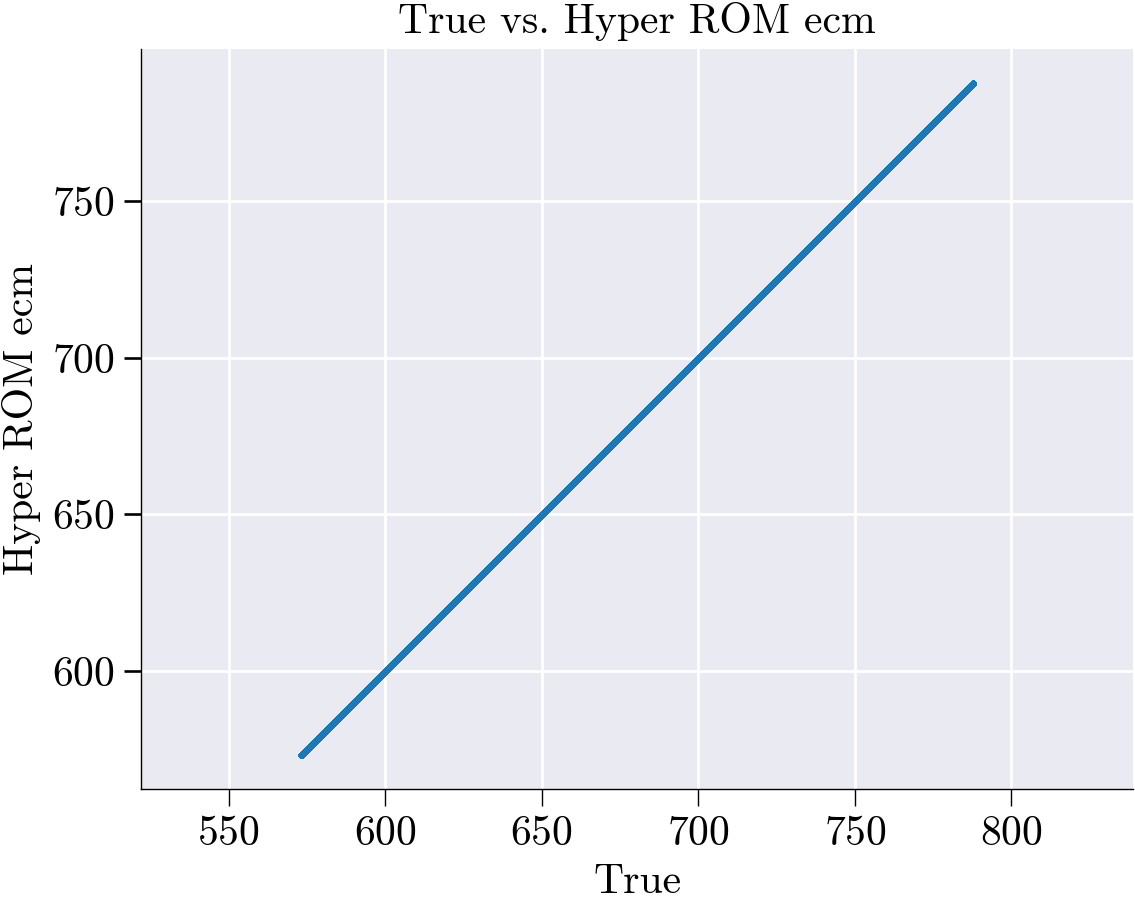

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


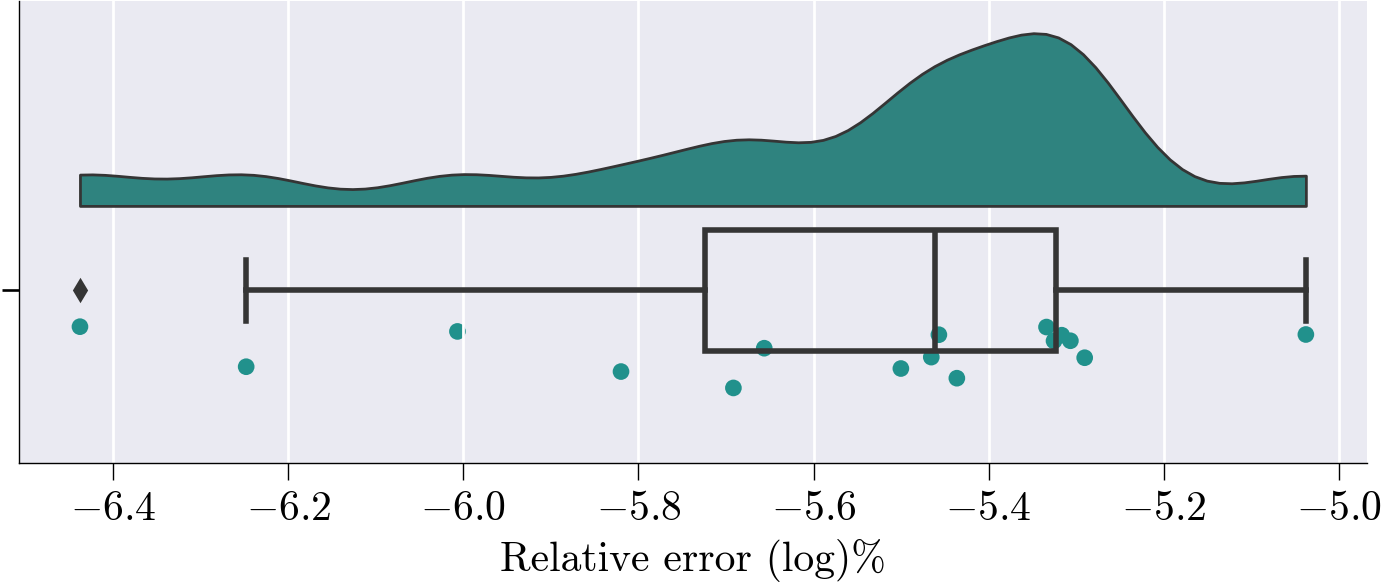

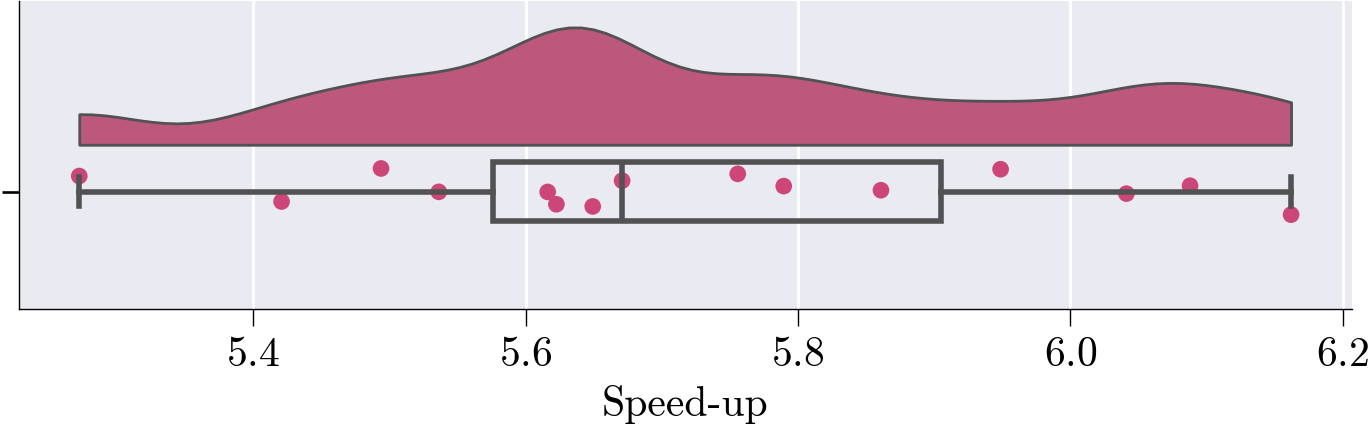

In [43]:
if _hyperreduce_ecm:

    # --- Hyper-reduced ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom_ecm)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        NLS_test,                   # full-order (true) solution snapshots
        NLS_hyper_rom_ecm,          # hyper-ROM-generated solution snapshots
        hyper_ROM_relative_error_ecm,   # precomputed relative error of the hyper-ROM
        hyper_ROM_speed_up_ecm,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'Hyper ROM ecm'], 
        metrics=matrix              # the matrix of error metrics just computed
    )



In [44]:
# fig, ax = plot_ecsw_weights(x_nnls_m)